# CNV Analysis Strategy (Figure S2)

**Manuscript Context:** This notebook contains the code and workflows used to generate **Figure S2a–i** for our study on Extranodal NK/T-cell lymphoma (ENKTCL).

**Objective:**
The goal of this analysis is to detail the computational strategy and stepwise refinement used to identify and characterize Copy Number Variations (CNVs) within the NK cell population. Specifically, we:
1. Perform CNV inference using inferCNVpy with stromal cells as reference. Visualize the CNV-based UMAP projection and corresponding heatmap to distinguish major malignant clusters from normal/stromal cells.
2. Subset the Normal NK population and refine its annotation by integrating sample origin (PBMC, Pre-ICI, Post-ICI) to ensure purity before comparative analysis.
3. Re-run CNV inference using Normal NK (PBMC) as the reference to enhance resolution of focal alterations (specifically in chr6p21). Visualize the distinct subclusters identified within the MalignNK_chr6p21Amp and MalignNK_chr6p21Del populations.
4. Generate an integrated UMAP and subcluster-specific CNV heatmap to confirm the spatial separation of malignant subclusters from normal NK cells and validate the presence of distinct focal CNV signatures (e.g., amplifications vs. deletions in chr6p21) across the identified subpopulations.

In [175]:
import anndata as ad
import matplotlib.pyplot as plt
import muon as mu
import pandas as pd
import scanpy as sc
import numpy as np
import os
import matplotlib as mpl
import matplotlib.ticker as ticker
mpl.rcParams['font.family'] = 'Arial'
figPath = "/home/rzh/ENKTCL-analysis/figures"
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.size"] = 14

Load RNA and IR h5ad data

In [899]:
figPath = "./figures/figS2"
NKPath = './data/NKTCL_NK.h5ad'
datPath = "./data/NKTCL_concat.h5ad"
os.makedirs(figPath, exist_ok=True)

In [ ]:
adata_NK = sc.read_h5ad(NKPath)
adata_concat = sc.read_h5ad(datPath)

Import cnv related libraries and chrom index

In [ ]:
import infercnvpy as cnv 
import pandas as pd
chrom = pd.read_csv("./data/gene_pos.txt", sep='\t', header=None)
chrom.columns = ["symbol", "ensg", "chromosome", "start", "end"]
chrom['ensg'] = [name.split('.')[0] for name in chrom['ensg']]
chrom.index = chrom['ensg']
chrom_ensg = chrom.copy()
chrom_ensg.index = chrom_ensg['ensg']
var_names = list(adata_concat.var['ID'][adata_concat.var['ID'].isin(chrom['ensg'])])
chrom_var_names = chrom.loc[var_names, :]
for i in range(len(var_names)):
    name = var_names[i]
    if name in chrom_ensg['ensg']:
        var_names[i] = chrom_ensg['symbol'][name]
chrom_var_names.index = var_names

Concat chrom index to gex file

In [180]:
adata_concat_cnv = adata_concat[:, adata_concat.var['ID'].isin(chrom['ensg'])]
adata_concat_cnv.var_names = var_names
adata_concat_cnv.var = pd.concat([adata_concat_cnv.var, chrom_var_names], axis=1)
adata_concat_cnv.var_names_make_unique()
adata_concat_cnv

/home/rzh/miniconda3/lib/python3.11/site-packages/anndata/_core/anndata.py:1793: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 170213 × 31852
    obs: 'batch', 'mt_frac', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'n_genes', 'n_counts', 'leiden-1', 'leiden-pca', 'anno-pca', 'treatment'
    var: 'ID', 'name', 'type', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'symbol', 'ensg', 'chromosome', 'start', 'end'
    uns: 'anno-pca_colors', 'batch_colors', 'dendrogram_anno-pca', 'hvg', 'leiden', 'leiden-1_colors', 'leiden-pca_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'treatment_colors', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    layers: 'Raw'
    obsp: 'connectivities', 'distances'

Perform InferCNV for immune cells with Stromal cells as reference

In [ ]:
adata_concat_ref = adata_concat_cnv[adata_concat_cnv.obs['anno-pca'].isin(
  ['Stromal cells'])]
adata_concat_NK = adata_concat_cnv[adata_concat_cnv.obs_names.isin(
  adata_NK.obs_names)]

In [182]:
def concat(adata1:ad.AnnData, adata2:ad.AnnData):
    adata1 = adata1.copy()
    adata2 = adata2.copy()
    adata1.obs['sample'] = adata1.obs['batch']
    adata2.obs['sample'] = adata2.obs['batch']
    adata_concat = adata1.concatenate(adata2)
    adata_concat.obs['batch'] = adata_concat.obs['sample']
    adata_concat.obs_names = [s[:-2] for s in adata_concat.obs_names]
    del adata_concat.obs['sample']
    return adata_concat

In [366]:
adata_concat_cnv = concat(adata_concat_ref, adata_concat_NK)
adata_concat_cnv

AnnData object with n_obs × n_vars = 30910 × 31852
    obs: 'batch', 'mt_frac', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'n_genes', 'n_counts', 'leiden-1', 'leiden-pca', 'anno-pca', 'treatment'
    var: 'ID', 'name', 'type', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'symbol', 'ensg', 'chromosome', 'start', 'end'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    layers: 'Raw'

In [367]:
cnv.tl.infercnv(adata_concat_cnv,reference_key="anno-pca", reference_cat=['Stromal cells'], layer='Raw')

  0%|          | 0/7 [00:00<?, ?it/s]

Perfrom cnv_umap for immune cells

In [368]:
cnv.tl.pca(adata_concat_cnv) 
cnv.pp.neighbors(adata_concat_cnv) 
cnv.tl.leiden(adata_concat_cnv)
cnv.tl.umap(adata_concat_cnv) 
cnv.tl.cnv_score(adata_concat_cnv)

In [ ]:
adata_concat.obs['LMP-1.1'] = adata_concat[:, 'LMP-1'].X.toarray().flatten()
adata_concat_cnv.obs['LMP-1'] = adata_concat.obs['LMP-1.1']

#### **Fig. S2b** CNV heatmap of NK cells and reference stromal cells showing genome-wide log2 fold change (LFC) signals relative to stromal cell references. 
Rows represent clusters and columns represent chromosomal regions. 

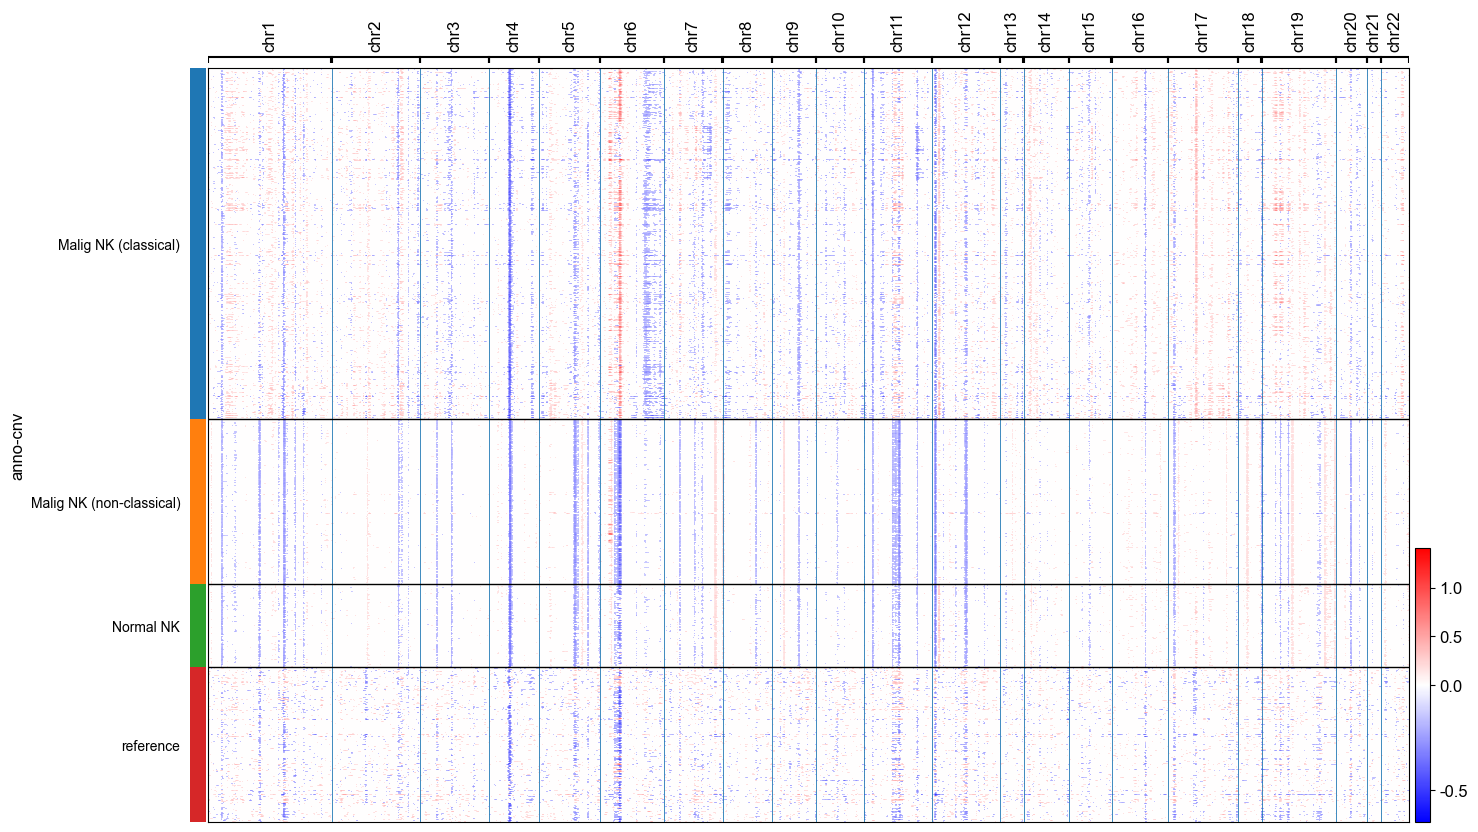

In [383]:
cnv.pl.chromosome_heatmap(adata_concat_cnv, groupby='anno-cnv')

##### **Fig. S2c** UMAP of normal NK cells colored by sample origin (PBMC, Pre-ICI, Post-ICI).

In [379]:
def anno(adata:ad.AnnData, annoDict:dict, obsKey='cnv_status', obsVal='cnv_leiden', default="Unknown"):
  if default is not None:
    adata.obs[obsKey] = default
  for key in annoDict.keys():
    adata.obs.loc[adata.obs[obsVal].isin(annoDict[key]), obsKey] = key
  adata.obs[obsKey] = adata.obs[obsKey].astype("category")
  return adata

In [380]:
annot = {
    'reference': ['3', '10', '11', '13'],
    'Normal NK': ['2'],
    'Malig NK (non-classical)': ['1', '6', '9'],
    'Malig NK (classical)': ['0', '4', '5', '7', '8', '12', '14', '15']
}
adata_concat_cnv = anno(adata_concat_cnv, annot, 'anno-cnv', 'cnv_leiden')


In [ ]:
def clu(adata, key_added="leiden-1", 
        n_neighbors=50, n_pcs=30, 
        rep='X_pca_harmony', 
        do_har=False, 
        max_iter=20, 
        do_scrublet=False, 
        har_key='batch', 
        resolution=1):
    # Computing the neighborhood graph
    if do_scrublet:
        n0 = adata.shape[0]
        print("{0} Cell number: {1}".format(key_added, n0))
        sc.external.pp.scrublet(adata)
        adata = adata[adata.obs['predicted_doublet']==False,:].copy()
        print("{0} Cells retained after scrublet, {1} cells reomved.".format(adata.shape[0], n0-adata.shape[0]))
    else:
        print("Ignoring processing doublet cells...")
    sc.pp.normalize_total(adata)
    sc.pp.log1p(adata)
    
    sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
    sc.pp.pca(adata, svd_solver='arpack', use_highly_variable=True)
    if do_har and len(adata.obs[har_key].cat.categories) > 1:
        sc.external.pp.harmony_integrate(adata, key=har_key,max_iter_harmony=max_iter)
        sc.pp.neighbors(adata, n_neighbors=n_neighbors, n_pcs=n_pcs, use_rep=rep)
    else:
        print("Evaluating neighbors only...")
        sc.pp.neighbors(adata, n_neighbors=n_neighbors, n_pcs=n_pcs, use_rep=rep)
    # Run UMAP
    sc.tl.umap(adata)
    sc.tl.leiden(adata, resolution=resolution, key_added=key_added)
    sc.pl.umap(adata, color=key_added, legend_fontoutline=True, palette=sc.pl.palettes.default_20, legend_loc="on data")
    return adata

Ignoring processing doublet cells...


2025-12-19 09:47:34,766 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
INFO	harmonypy:harmony.py:_cluster_kmeans()- Computing initial centroids with sklearn.KMeans...
2025-12-19 09:47:35,685 - harmonypy - INFO - sklearn.KMeans initialization complete.
INFO	harmonypy:harmony.py:_cluster_kmeans()- sklearn.KMeans initialization complete.
2025-12-19 09:47:35,703 - harmonypy - INFO - Iteration 1 of 20
INFO	harmonypy:harmony.py:harmonize()- Iteration 1 of 20
2025-12-19 09:47:36,239 - harmonypy - INFO - Iteration 2 of 20
INFO	harmonypy:harmony.py:harmonize()- Iteration 2 of 20
2025-12-19 09:47:36,771 - harmonypy - INFO - Iteration 3 of 20
INFO	harmonypy:harmony.py:harmonize()- Iteration 3 of 20
2025-12-19 09:47:37,303 - harmonypy - INFO - Iteration 4 of 20
INFO	harmonypy:harmony.py:harmonize()- Iteration 4 of 20
2025-12-19 09:47:37,815 - harmonypy - INFO - Iteration 5 of 20
INFO	harmonypy:harmony.py:harmonize()- Iteration 5 of 20
2025-12-19 09:47:38,187 - harmonypy - 

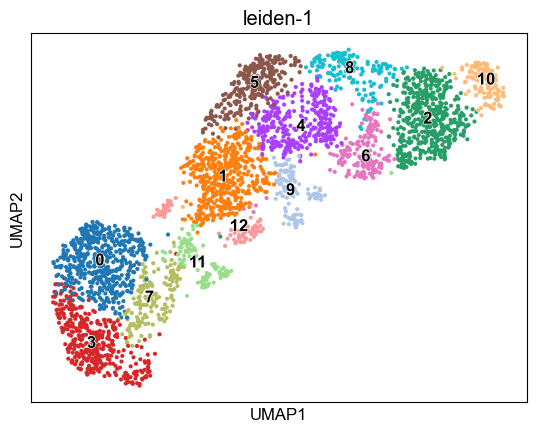

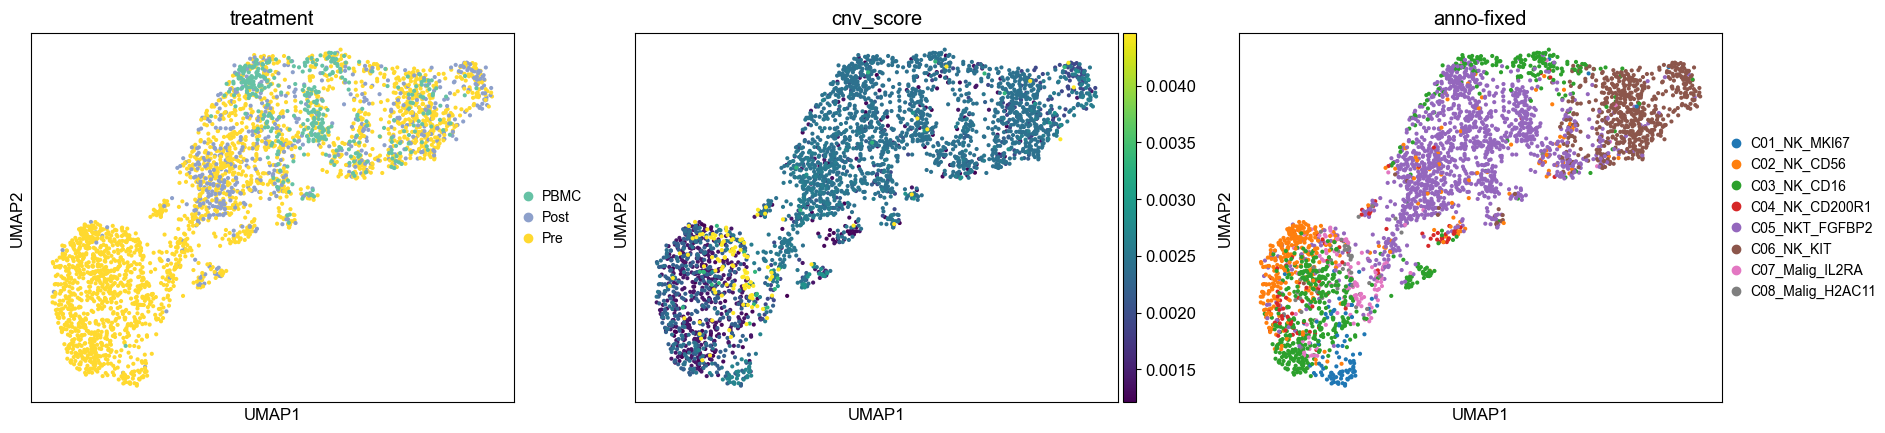

In [398]:
# refine the normal NK
adata_NK.obs['anno-cnv'] = adata_concat_cnv.obs['anno-cnv']
adata_NM = adata_NK[adata_NK.obs['anno-cnv'].isin(['Normal NK'])]
adata_NM = clu(adata_NM, do_har=True, do_scrublet=False)
sc.pl.umap(adata_NM, color=['treatment',  'cnv_score', 'anno-fixed'])

##### **Fig. 3d** UMAP of normal NK cells colored by annotations after Normal NK refinement.

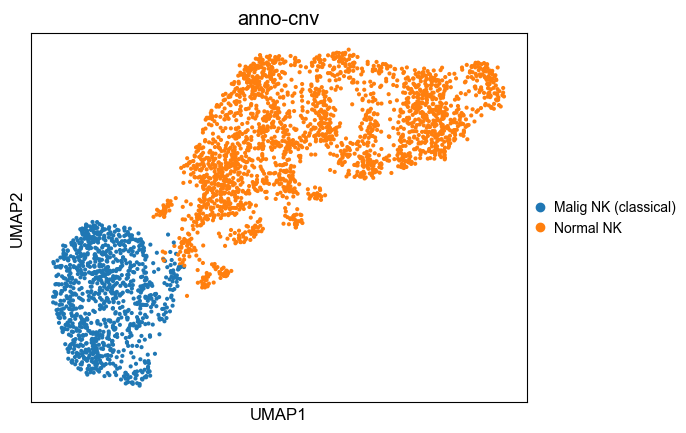

In [399]:
# The normal NK in first-level has some malignant NK cells, refine them and perform CNV again
annot = {
    'Malig NK (classical)': ['0', '3', '7'],
    'Normal NK': ['1', '2', '4', '5', '6', '8', '9', '10', '11', '12'],
}
adata_NM = anno(adata_NM, annot, 'anno-cnv', 'leiden-1')
sc.pl.umap(adata_NM, color=['anno-cnv'])

#### **Fig. S2a** CNV UMAP projection of NK cells and stromal cells colored by CNV-based Leiden clusters (generated via cnv.tl.leiden in inferCNVpy).

In [211]:
def merge(adata1, adata2, obs1, obs2):
    adata1.obs[obs1] = list(adata1.obs[obs1])
    valid_obs = adata2.obs_names[adata2.obs_names.isin(adata1.obs_names)]
    adata1.obs.loc[valid_obs, obs1] = adata2.obs[obs2]
    adata1.obs[obs1] = adata1.obs[obs1].astype('category')
    return adata1

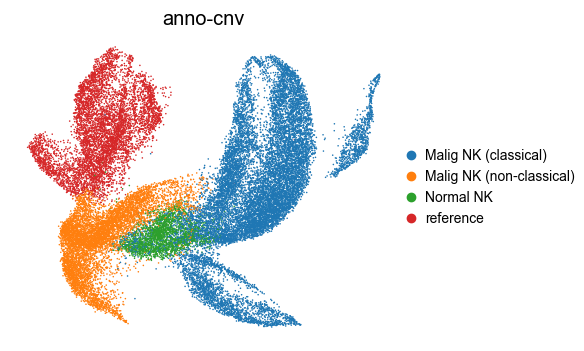

In [ ]:
adata_concat_cnv = merge(adata_concat_cnv, adata_NM, 'anno-cnv', 'anno-cnv')
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
cnv.pl.umap(adata_concat_cnv, color=['anno-cnv'], size=5, ax=ax, show=False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_xlabel("")
ax.set_ylabel("")
# ax.legend(  handletextpad=0.5, frameon=False,
#                     borderpad=0.6,
#                     columnspacing=1.3,
#                     handlelength=0.65, fontsize=12)
fig.savefig(f"{figPath}/FigS2a.png", dpi=400, bbox_inches='tight')

#### **Fig. S2e** CNV heatmap of NK cells with Normal NK (PBMC) as the reference, highlighting enhanced resolution of focal chr6p21 amplification/deletion in malignant clusters.

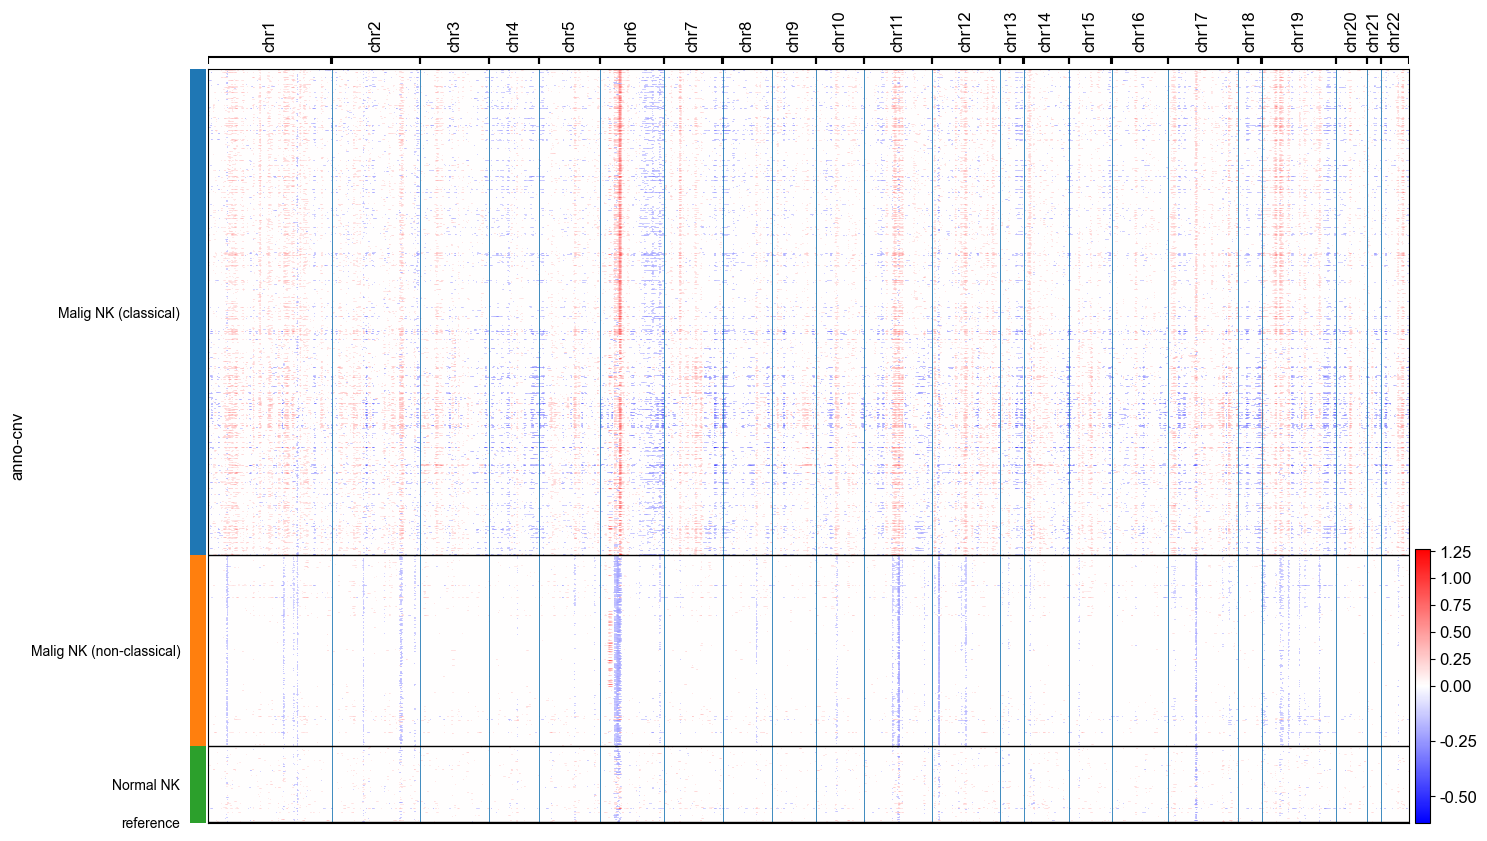

In [ ]:
cnv.pl.chromosome_heatmap(adata_concat_cnv, groupby='anno-cnv')

#### **Fig. S2f** UMAP of MalignNK_chr6p21Amp subclusters, colored by subcluster identity.

Ignoring processing doublet cells...


/home/rzh/miniconda3/lib/python3.11/site-packages/scanpy/preprocessing/_normalization.py:269: UserWarning:

Received a view of an AnnData. Making a copy.



/home/rzh/miniconda3/lib/python3.11/site-packages/scanpy/preprocessing/_pca/__init__.py:227: FutureWarning:

Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None

2025-10-15 10:07:07,350 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
INFO	harmonypy:harmony.py:_cluster_kmeans()- Computing initial centroids with sklearn.KMeans...
2025-10-15 10:07:09,886 - harmonypy - INFO - sklearn.KMeans initialization complete.
INFO	harmonypy:harmony.py:_cluster_kmeans()- sklearn.KMeans initialization complete.
2025-10-15 10:07:09,924 - harmonypy - INFO - Iteration 1 of 20
INFO	harmonypy:harmony.py:harmonize()- Iteration 1 of 20
2025-10-15 10:07:13,053 - harmonypy - INFO - Iteration 2 of 20
INFO	harmonypy:harmony.py:harmonize()- Iteration 2 of 20
2025-10-15 10:07:16,205 - harmonypy - INFO - Converged after 2 iteratio

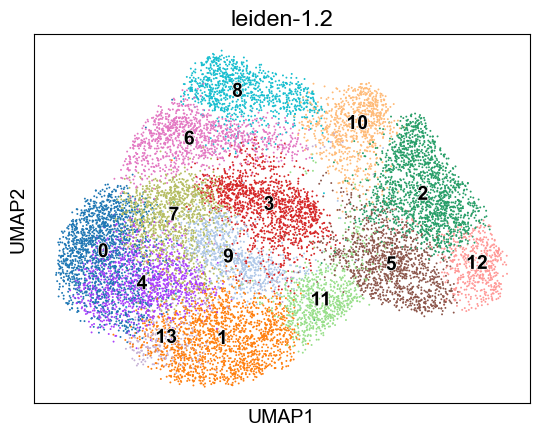

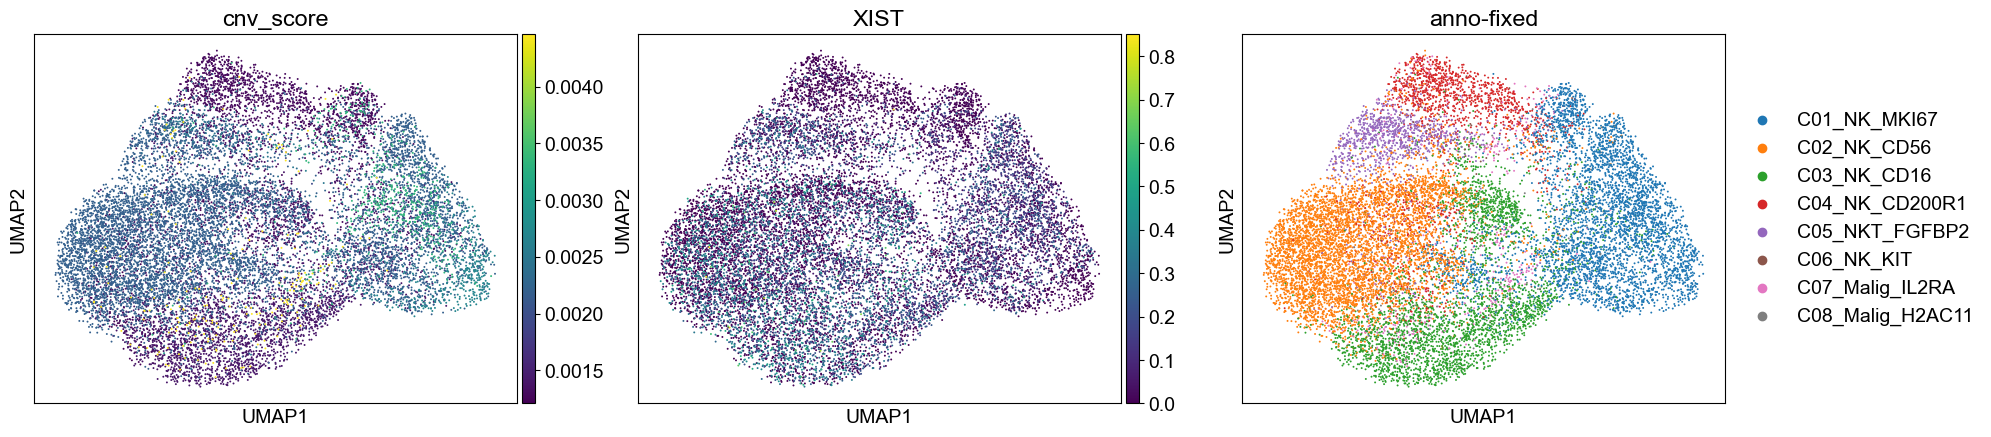

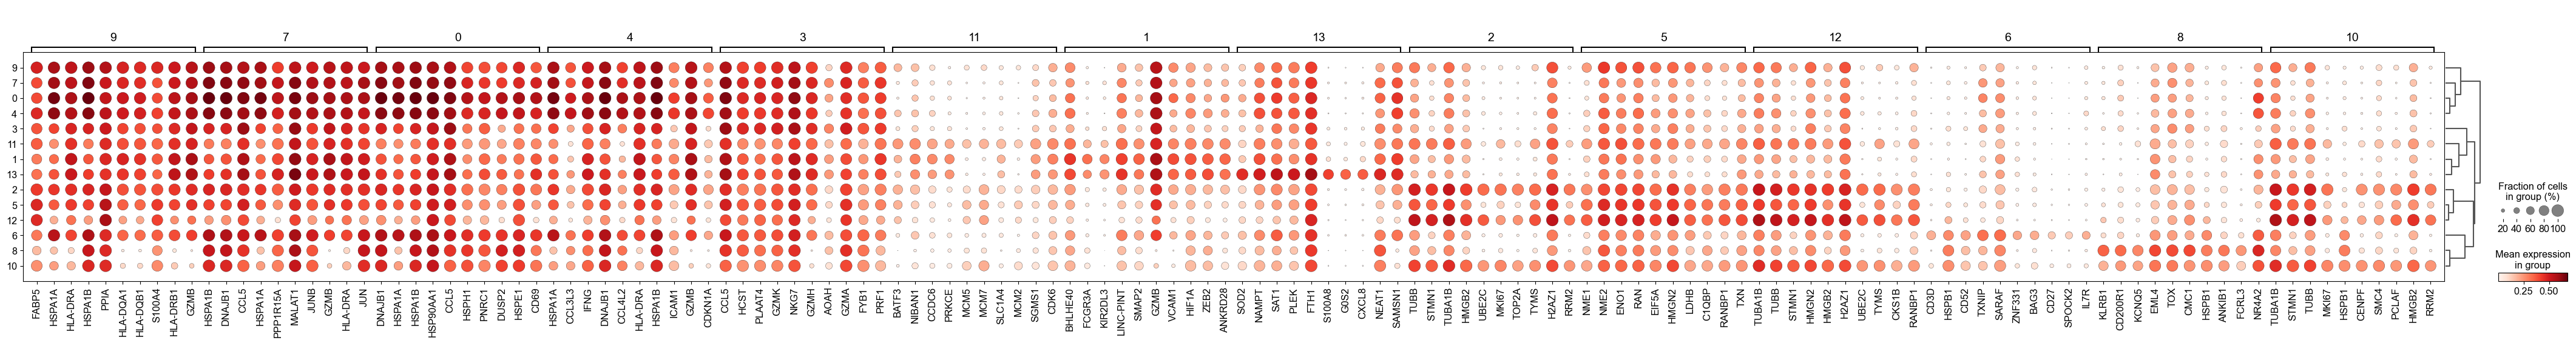

In [ ]:
# perform second-level unsupervised clustering based on anno-cnv from CNV analysis
adata_C = adata_NK[adata_NK.obs['anno-cnv'].isin(['Malig NK (classical)'])]
adata_C = clu(adata_C, do_har=True, do_scrublet=False, resolution=1.2, key_added='leiden-1.2')
sc.pl.umap(adata_C, color=['cnv_score', 'XIST', 'anno-fixed'])
sc.tl.rank_genes_groups(adata_C, groupby='leiden-1.2')
sc.tl.dendrogram(adata_C, groupby='leiden-1.2')
sc.pl.rank_genes_groups_dotplot(adata_C)

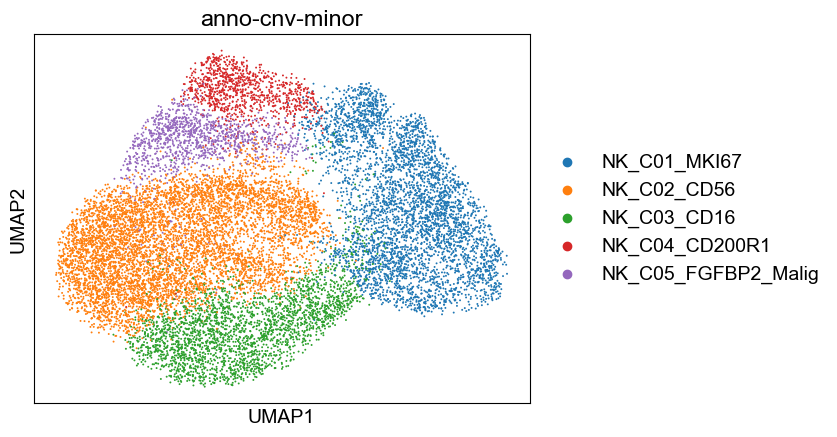

In [ ]:
annot = {
    'NK_C01_MKI67': ['2', '5', '10', '12'],
    'NK_C02_CD56': ['0', '3', '4', '7', '9'],
    'NK_C03_CD16': ['1', '11', '13'],
    'NK_C04_CD200R1': ['8'],
    'NK_C05_FGFBP2_Malig': ['6'],
}
adata_C = anno(adata_C, annot, 'anno-cnv-minor', 'leiden-1.2')
sc.pl.umap(adata_C, color='anno-cnv-minor')

#### **Fig. S2g** UMAP of MalignNK_chr6p21Del subclusters, colored by subcluster identity.

Ignoring processing doublet cells...


/home/rzh/miniconda3/lib/python3.11/site-packages/scanpy/preprocessing/_normalization.py:269: UserWarning:

Received a view of an AnnData. Making a copy.

/home/rzh/miniconda3/lib/python3.11/site-packages/scanpy/preprocessing/_pca/__init__.py:227: FutureWarning:

Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None

2025-10-15 10:09:02,057 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
INFO	harmonypy:harmony.py:_cluster_kmeans()- Computing initial centroids with sklearn.KMeans...
2025-10-15 10:09:03,119 - harmonypy - INFO - sklearn.KMeans initialization complete.
INFO	harmonypy:harmony.py:_cluster_kmeans()- sklearn.KMeans initialization complete.
2025-10-15 10:09:03,142 - harmonypy - INFO - Iteration 1 of 20
INFO	harmonypy:harmony.py:harmonize()- Iteration 1 of 20
2025-10-15 10:09:04,344 - harmonypy 

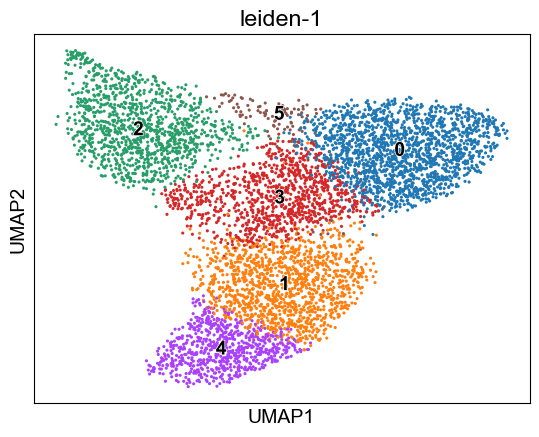

In [ ]:
adata_NC = adata_NK[adata_NK.obs['anno-cnv'].isin(['Malig NK (non-classical)'])]
adata_NC = clu(adata_NC, do_har=True, do_scrublet=False)

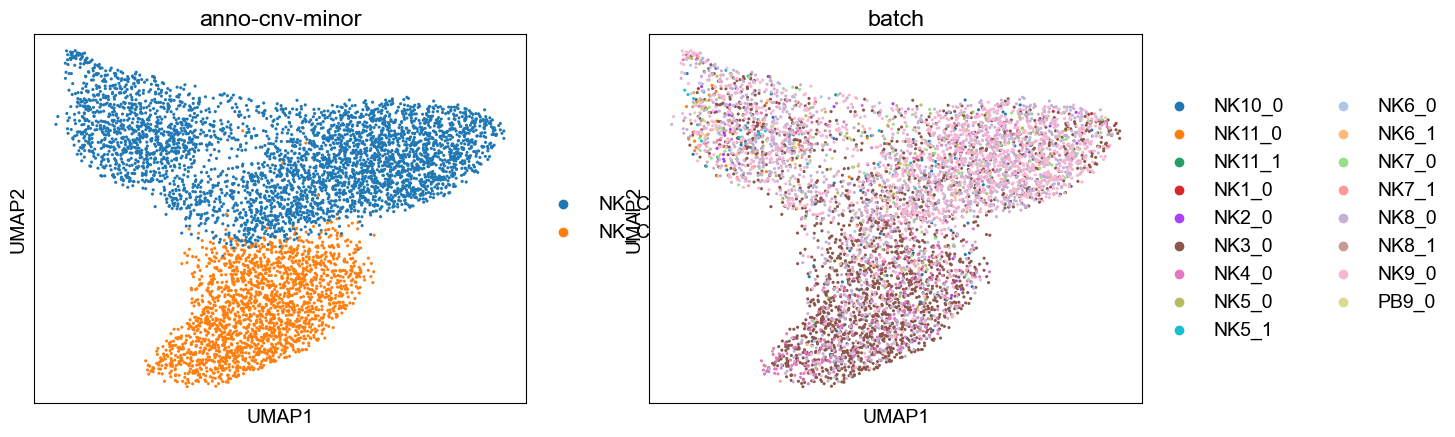

In [ ]:
annot = {
    'NK_C07_IL2RA': ['0', '2', '3', '5'],
    'NK_C08_H2AC11': ['1', '4'],
}
adata_NC = anno(adata_NC, annot, 'anno-cnv-minor', 'leiden-1')
sc.pl.umap(adata_NC, color=['anno-cnv-minor', 'batch'])

#### **Fig. S2h** UMAP of all NK subclusters (integrating MalignNK_chr6p21Amp, MalignNK_chr6p21Del, and Normal NK), showing distinct spatial separation of malignant vs. normal populations. 

Ignoring processing doublet cells...


/home/rzh/miniconda3/lib/python3.11/site-packages/scanpy/preprocessing/_normalization.py:269: UserWarning:

Received a view of an AnnData. Making a copy.

/home/rzh/miniconda3/lib/python3.11/site-packages/scanpy/preprocessing/_pca/__init__.py:227: FutureWarning:

Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None

2025-10-15 10:10:29,980 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
INFO	harmonypy:harmony.py:_cluster_kmeans()- Computing initial centroids with sklearn.KMeans...
2025-10-15 10:10:30,665 - harmonypy - INFO - sklearn.KMeans initialization complete.
INFO	harmonypy:harmony.py:_cluster_kmeans()- sklearn.KMeans initialization complete.
2025-10-15 10:10:30,674 - harmonypy - INFO - Iteration 1 of 50
INFO	harmonypy:harmony.py:harmonize()- Iteration 1 of 50
2025-10-15 10:10:31,039 - harmonypy 

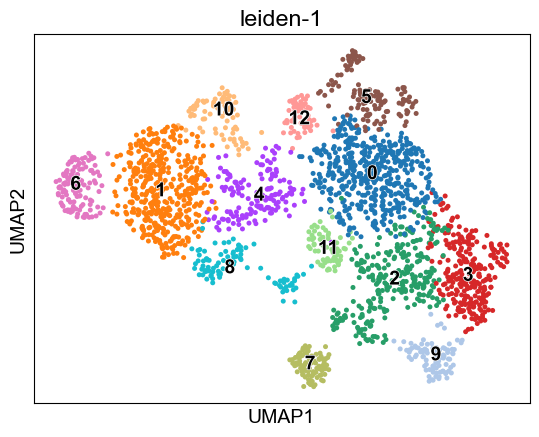

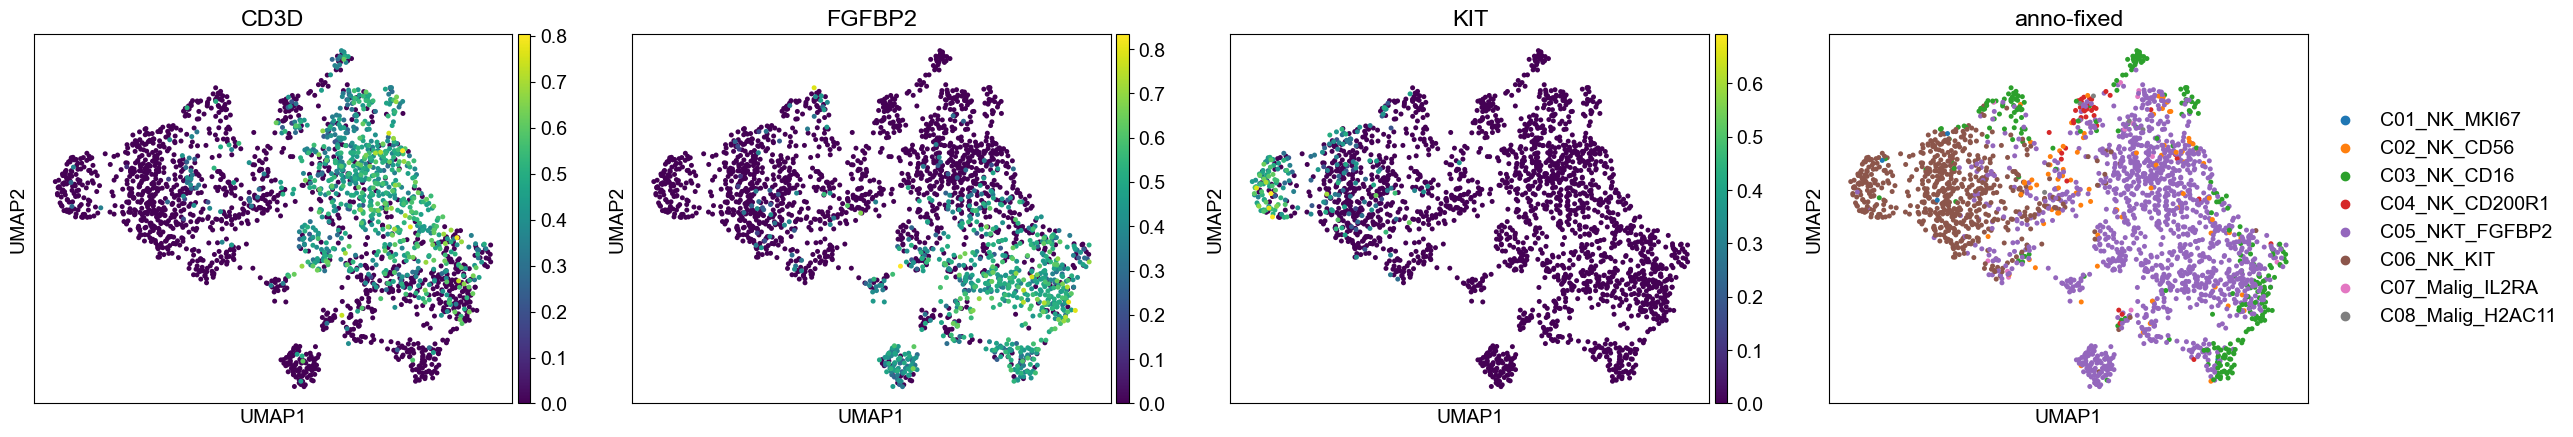

In [ ]:
adata_NM = adata_NK[adata_NK.obs['anno-cnv'].isin(['Normal NK'])]
adata_NM = clu(adata_NM, do_har=True, do_scrublet=False, max_iter=50)
sc.pl.umap(adata_NM, color=['CD3D', 'FGFBP2', 'KIT', 'anno-fixed'])

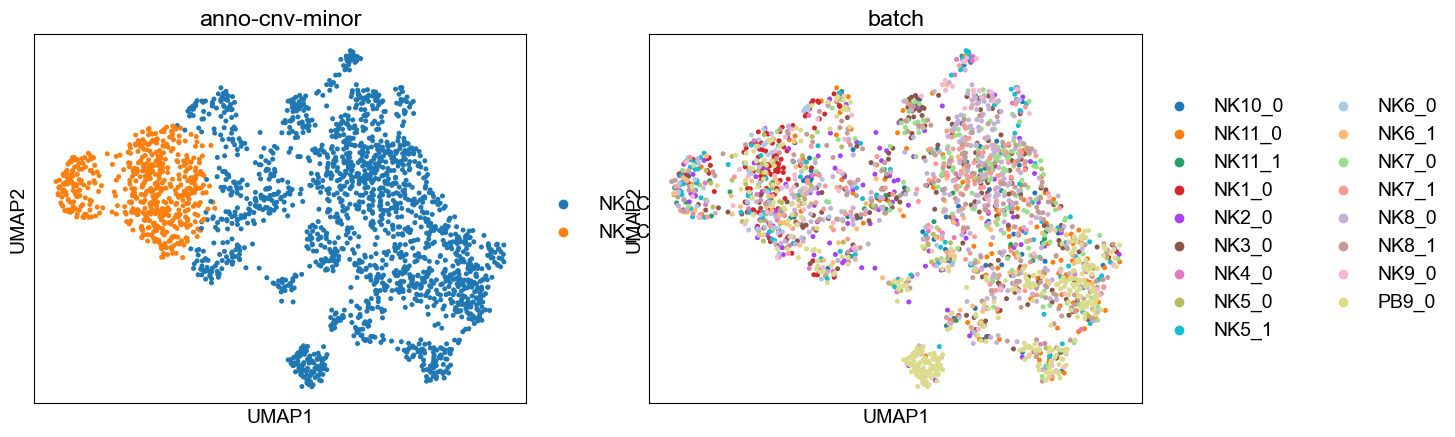

In [ ]:
annot = {
    'NK_C05_FGFBP2_Norm': ['0', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12'],
    'NK_C06_KIT': ['1', '6'],
}
adata_NM = anno(adata_NM, annot, 'anno-cnv-minor', 'leiden-1')
sc.pl.umap(adata_NM, color=['anno-cnv-minor', 'batch'])

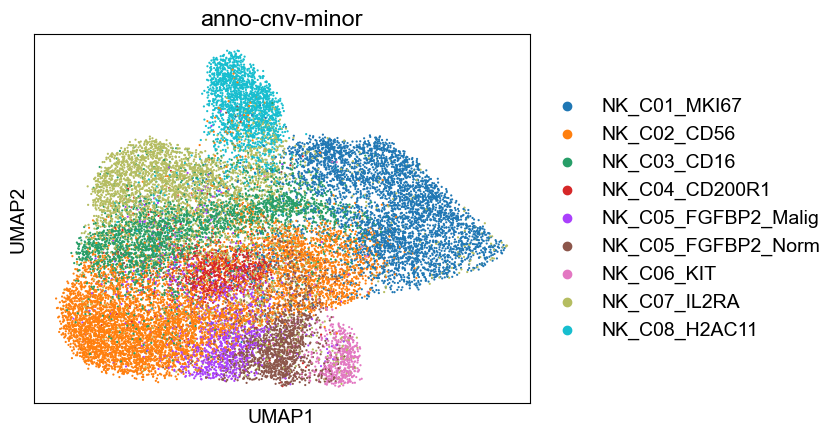

In [ ]:
annot = {
    'NK_C01_MKI67': ['C01_NK_MKI67'], 
    'NK_C02_CD56': ['C02_NK_CD56'], 
    'NK_C03_CD16': ['C03_NK_CD16'], 
    'NK_C04_CD200R1': ['C04_NK_CD200R1'],
    'NK_C05_FGFBP2_Norm': ['C05_NKT_FGFBP2'], 
    'NK_C06_KIT': ['C06_NK_KIT'], 
    'NK_C07_IL2RA': ['C07_Malig_IL2RA'], 
    'NK_C08_H2AC11': ['C08_Malig_H2AC11']
}
adata_NK = anno(adata_NK, annot, 'anno-cnv-minor', 'anno-fixed')
adata_NK = merge(adata_NK, adata_C, 'anno-cnv-minor', 'anno-cnv-minor')
adata_NK = merge(adata_NK, adata_NC, 'anno-cnv-minor', 'anno-cnv-minor')
adata_NK = merge(adata_NK, adata_NM, 'anno-cnv-minor', 'anno-cnv-minor')
sc.pl.umap(adata_NK, color=['anno-cnv-minor'], size=10)

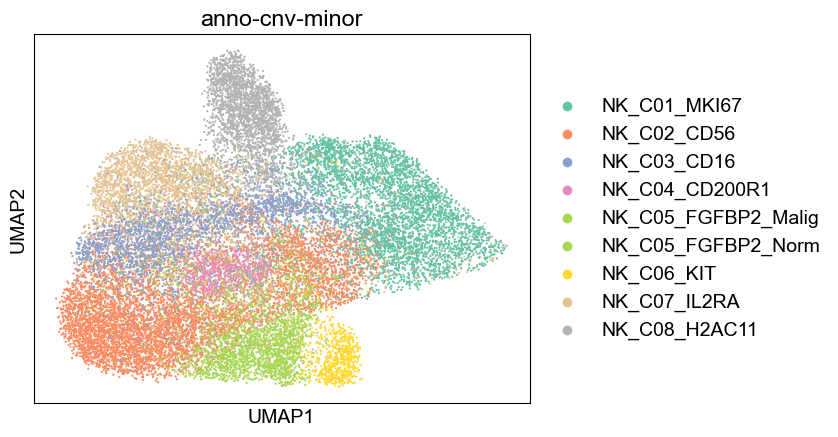

In [ ]:
# refine anno-cnv-minor by previous unsupervised clustering
annot = {
    'NK_C06_KIT': ['C06_NK_KIT'], 
    'NK_C08_H2AC11': ['C08_Malig_H2AC11']
}
adata_NK = anno(adata_NK, annot, 'anno-cnv-minor', 'anno-fixed', default=None)
sc.pl.umap(adata_NK, color='anno-cnv-minor', size=10, palette=['#66c2a5', '#fc8d62', 
          '#8da0cb', '#e78ac3', '#a6d854', '#a6d854','#ffd92f', '#e5c494', '#b3b3b3'])

#### **Fig. S2i** CNV heatmap of NK subclusters (from panel h), confirming subcluster-specific focal CNV signa-tures (e.g., chr6p21 amplification in NK01–NK05, chr6p21 deletion in NK08–NK09) and ab-sence of CNV signals in normal NK subclusters.

  0%|          | 0/5 [00:00<?, ?it/s]

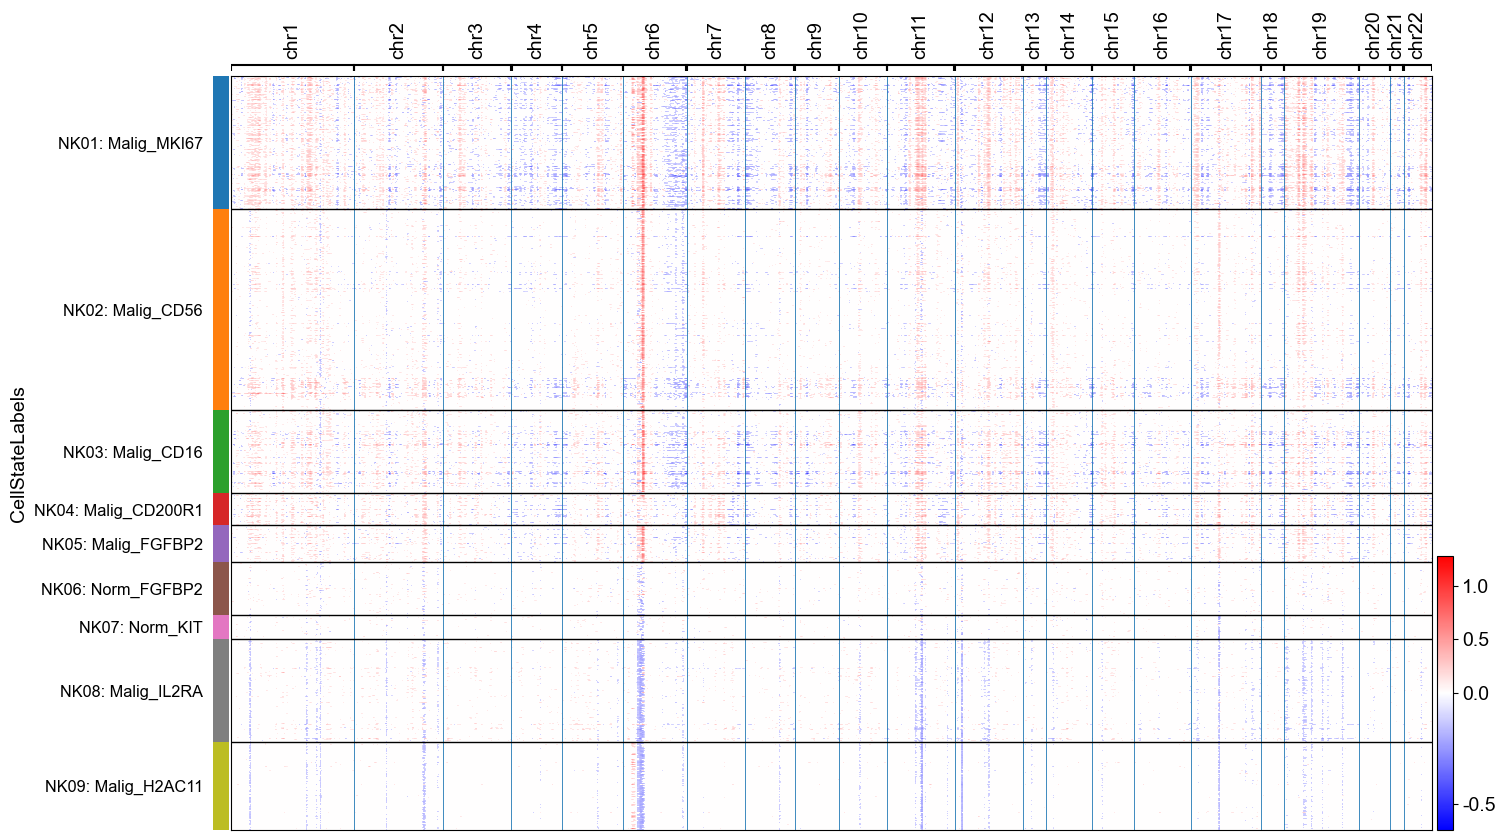

In [ ]:
# using the Normal NK to aviod the noise in reference cells
adata_concat_cnv.obs['anno-cnv'] = adata_NK.obs['anno-cnv']
adata_concat_cnv.obs['anno-cnv-minor'] = adata_NK.obs['anno-cnv-minor']
adata_concat_cnv.obs['CellStateLabels'] = adata_NK.obs['CellStateLabels']
adata_concat_cnv1 = adata_concat_cnv[adata_concat_cnv.obs_names.isin(adata_NK.obs_names)].copy()
cnv.tl.infercnv(adata_concat_cnv1,reference_key="anno-cnv", reference_cat=['Normal NK'], layer='Raw', calculate_gene_values=True, n_jobs=32)
cnv.pl.chromosome_heatmap(adata_concat_cnv1, groupby='CellStateLabels', save='FigS2i.pdf')